In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11
})
from biot_gassmann import gassmann,biot_gassmann_wood,biot_gassmann_hill
from wiff_layer import white_layer_1975,biot_layer_matrix,dynamic_biot_layer_matrix

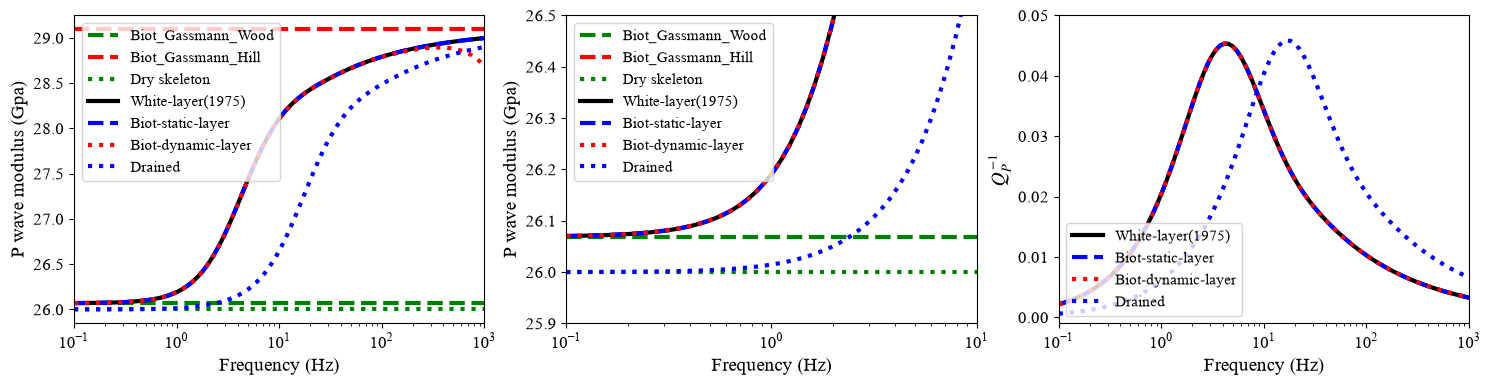

In [3]:
Ks   = 38e9 # Pa
Gs   = 44e9
rhos = 2.65e3 # Kg/m^3
Kd   = 10e9
Gd   = 12e9
phi  = 0.15
perm0= 10e-15 # 10 mD
f    = np.logspace(-1,3,100)
# Upper layer
Kf_up   = 2.4e9
rhof_up = 1e3
vis_up  = 1e-3 # Pa·s
# Lower layer
Kf_low   = 9.6e6
rhof_low = 50
vis_low  = 1e-5 # Pa·s

rock_up  = [Ks,Gs,rhos,Kd,Gd,phi]
fluid_up = [Kf_up,rhof_up,vis_up]
rock_low = [Ks,Gs,rhos,Kd,Gd,phi]
fluid_low= [Kf_low,rhof_low,vis_low]
perm     = [perm0,perm0]
d1       = 0.2
d2       = 0.2

H_white,Vp_white,invQp_white = white_layer_1975(rock_up,rock_low,fluid_up,fluid_low,perm,d1,d2,f)
H_static  = biot_layer_matrix(rock_up,rock_low,fluid_up,fluid_low,perm,d1,d2,f,Pc=15e3,undrained=1,Pf_out=0)[0]
H_dynamic = dynamic_biot_layer_matrix(rock_up,rock_low,fluid_up,fluid_low,perm,d1,d2,f,s=[1,1],Pc=15e3,undrained=1,Pf_out=0)[0]
H_drained = biot_layer_matrix(rock_up,rock_low,fluid_up,fluid_low,perm,d1,d2,f,Pc=15e3,undrained=0,Pf_out=0)[0]

fraction = [d1/(d1+d2),d2/(d1+d2)]
Kf = [Kf_up,Kf_low]
H_lower = biot_gassmann_wood(Kd,Gd,Ks,Kf,phi,fraction)
H_high  = biot_gassmann_hill(Kd,Gd,Ks,Kf,phi,fraction)
H_dry   = Kd + 4/3*Gd

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.semilogx([f.min(),f.max()],[H_lower/1e9,H_lower/1e9],
             label='Biot_Gassmann_Wood',color='green',linestyle='--',linewidth=3)
plt.semilogx([f.min(),f.max()],[H_high/1e9,H_high/1e9],
             label='Biot_Gassmann_Hill',color='red',linestyle='--',linewidth=3)
plt.semilogx([f.min(),f.max()],[H_dry/1e9,H_dry/1e9],
             label='Dry skeleton',color='green',linestyle=':',linewidth=3)
plt.semilogx(f,np.real(H_white)/1e9,
             label='White-layer(1975)',color='black',linewidth=3)
plt.semilogx(f,np.real(H_static)/1e9,
             label='Biot-static-layer',color='blue',linestyle='--',linewidth=3)
plt.semilogx(f,np.real(H_dynamic)/1e9,
             label='Biot-dynamic-layer',color='red',linestyle=':',linewidth=3)
plt.semilogx(f,np.real(H_drained)/1e9,
             label='Drained',color='blue',linestyle=':',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('P wave modulus (Gpa)')
plt.legend(loc='upper left')
plt.xlim(f.min(),f.max())

plt.subplot(1,3,2)
plt.semilogx([f.min(),f.max()],[H_lower/1e9,H_lower/1e9],
             label='Biot_Gassmann_Wood',color='green',linestyle='--',linewidth=3)
plt.semilogx([f.min(),f.max()],[H_high/1e9,H_high/1e9],
             label='Biot_Gassmann_Hill',color='red',linestyle='--',linewidth=3)
plt.semilogx([f.min(),f.max()],[H_dry/1e9,H_dry/1e9],
             label='Dry skeleton',color='green',linestyle=':',linewidth=3)
plt.semilogx(f,np.real(H_white)/1e9,
             label='White-layer(1975)',color='black',linewidth=3)
plt.semilogx(f,np.real(H_static)/1e9,
             label='Biot-static-layer',color='blue',linestyle='--',linewidth=3)
plt.semilogx(f,np.real(H_dynamic)/1e9,
             label='Biot-dynamic-layer',color='red',linestyle=':',linewidth=3)
plt.semilogx(f,np.real(H_drained)/1e9,
             label='Drained',color='blue',linestyle=':',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('P wave modulus (Gpa)')
plt.legend(loc='upper left')
plt.xlim(1e-1,1e1)
plt.xticks([1e-1,1e0,1e1])
plt.ylim(25.9,26.5)

plt.subplot(1,3,3)
plt.semilogx(f,np.imag(H_white)/np.real(H_white),
             label='White-layer(1975)',color='black',linewidth=3)
plt.semilogx(f,np.imag(H_static)/np.real(H_static),
             label='Biot-static-layer',color='blue',linestyle='--',linewidth=3)
plt.semilogx(f,np.imag(H_dynamic)/np.real(H_dynamic),
             label='Biot-dynamic-layer',color='red',linestyle=':',linewidth=3)
plt.semilogx(f,np.imag(H_drained)/np.real(H_drained),
             label='Drained',color='blue',linestyle=':',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'$Q_{P}^{-1}$')
plt.legend(loc='lower left')
plt.xlim(f.min(),f.max())
plt.ylim(-0.001,0.05)

plt.show()

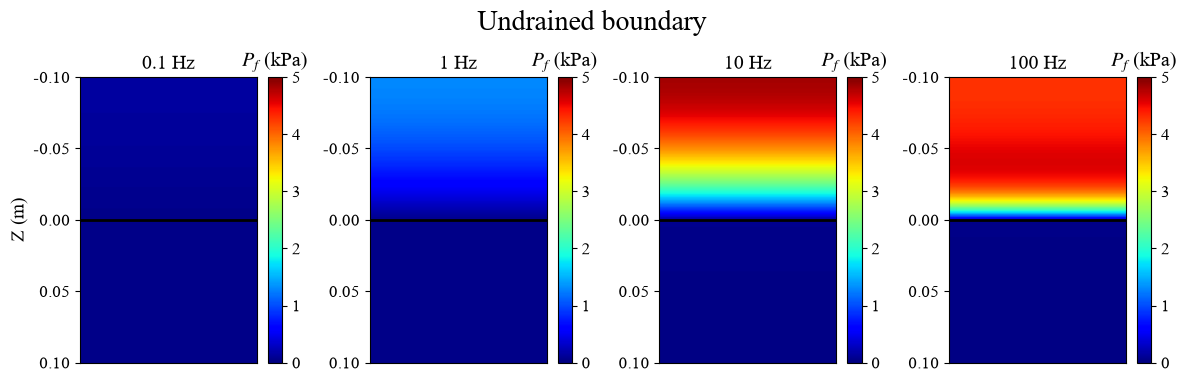

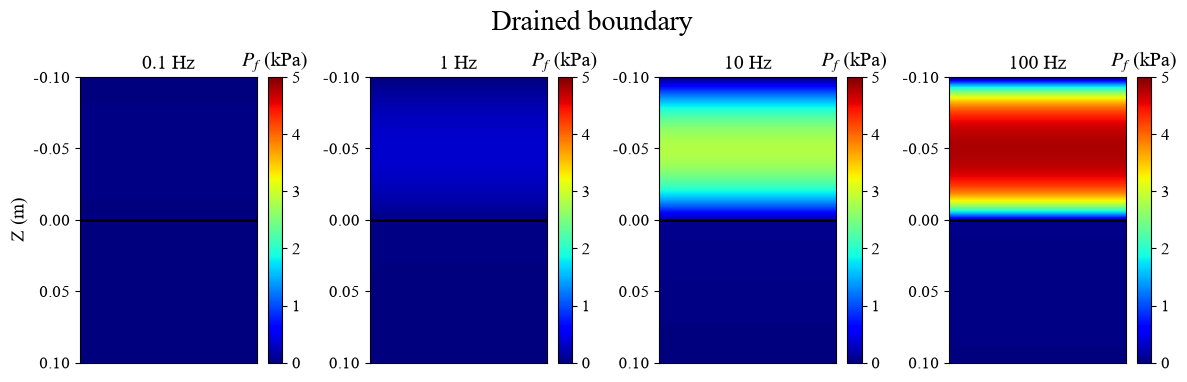

In [5]:
f  = [0.1,1,10,100]
x = np.arange(10)
h = biot_layer_matrix(rock_up,rock_low,fluid_up,fluid_low,perm,d1,d2,f[0],Pc=15e3,undrained=1,Pf_out=0)[1]
pf_close = np.zeros((len(f),len(h)),dtype=np.complex128)
pf_open  = np.zeros((len(f),len(h)),dtype=np.complex128)
# close boundary
for i in range(len(f)):
    pf_close[i,:] = biot_layer_matrix(rock_up,rock_low,fluid_up,fluid_low,perm,d1,d2,f[i],Pc=15e3,undrained=1,Pf_out=0)[2]
# open baundary
for i in range(len(f)):
    pf_open[i,:] = biot_layer_matrix(rock_up,rock_low,fluid_up,fluid_low,perm,d1,d2,f[i],Pc=15e3,undrained=0,Pf_out=0)[2]

plt.figure(figsize=(12,4))
for i in range(len(f)):
    plt.subplot(1,4,i+1)
    pf_abs = np.abs(pf_close[i,:])/1e3
    pf_2d = np.tile(pf_abs[:, None], (1, len(x)))
    im = plt.imshow(pf_2d,extent=[x.min(),x.max(),h.min(),h.max()],
           aspect='auto',cmap='jet',vmin=0,vmax=5)
    cbar = plt.colorbar(im)
    cbar.ax.set_title(r'$P_f$ (kPa)',pad=8)
    plt.plot([x.min(),x.max()],[0,0],'k-',linewidth=2)
    plt.xticks([])
    if i == 0:
        plt.ylabel('Z (m)')
    plt.yticks([-0.1,-0.05,0,0.05,0.1],
               labels=['0.10','0.05','0.00','-0.05','-0.10'])
    plt.xticks
    plt.title(f'{f[i]} Hz')
plt.suptitle('Undrained boundary',fontsize=20,y=0.95)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
for i in range(len(f)):
    plt.subplot(1,4,i+1)
    pf_abs = np.abs(pf_open[i,:])/1e3
    pf_2d = np.tile(pf_abs[:, None], (1, len(x)))
    im = plt.imshow(pf_2d,extent=[x.min(),x.max(),h.min(),h.max()],
                    aspect='auto',cmap='jet',vmin=0,vmax=5)
    cbar = plt.colorbar(im)
    cbar.ax.set_title(r'$P_f$ (kPa)',pad=8)
    plt.plot([x.min(),x.max()],[0,0],'k-',linewidth=2)
    plt.xticks([])
    if i == 0:
        plt.ylabel('Z (m)')
    plt.yticks([-0.1,-0.05,0,0.05,0.1],
               labels=['0.10','0.05','0.00','-0.05','-0.10'])
    plt.title(f'{f[i]} Hz')
plt.suptitle('Drained boundary',fontsize=20,y=0.95)
plt.tight_layout()
plt.show()